## 1. Import Required Libraries

We start by importing all necessary libraries for model training, data handling, and visualization. PyTorch is our deep learning framework, torchvision provides pre-trained models, and sklearn gives us metrics for evaluation.

In [2]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.models as tm
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.image as mpimg
from pathlib import Path

# Try to import EfficientNet (if timm is installed)
try:
    from timm import create_model
    print("✓ timm library loaded successfully")
except ImportError:
    print("Installing timm...")
    os.system('pip install timm')
    from timm import create_model

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✓ timm library loaded successfully
Using device: cpu


## 2. Define Data Paths

Set up the directory paths where your training and test images are stored. The folder structure should have two subdirectories: 'training' and 'testing', each containing 'flip' and 'notflip' class folders.

In [3]:
# Set folder paths - UPDATE THIS TO YOUR DATA PATH
base_dir = r"C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images"
train_dir = os.path.join(base_dir, 'training')  # Training data path
test_dir = os.path.join(base_dir, 'testing')    # Test data path

# Verify paths exist
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

Train directory: C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\training
Test directory: C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\testing
Train directory exists: True
Test directory exists: True


### 2. Create a transform for the input data

Before feeding data into a model, we often need to clean it up or adjust it. For images, this might mean cropping, resizing, applying transformations, or normalizing values. PyTorch’s torchvision library makes this easy by offering many built‑in “transforms.” You can even chain several of them together in order using the Compose function

In [4]:
# For EfficientNet, input size should be 224x224 (standard for both models)
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(p=0.3),  # Pages might flip horizontally too
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

print("✓ Transforms defined successfully")

✓ Transforms defined successfully


### 3. Load and Split Datasets

We load the image dataset from folders and split it into training, validation, and test sets. The training set is split 85/15 for training and validation. This validation set helps us tune hyperparameters and prevent overfitting.

In [5]:
# Load datasets
full_train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
print(f"Classes: {class_names}")  # should print ['flip', 'notflip']

# Split training data into train and validation (85% train, 15% val)
val_size = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],generator=torch.Generator().manual_seed(4231))

print(f"\nDataset sizes:")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataLoader batches:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Classes: ['flip', 'notflip']

Dataset sizes:
Training samples: 2034
Validation samples: 358
Test samples: 597

DataLoader batches:
Train batches: 64
Val batches: 12
Test batches: 19


### 4. plot some Pics

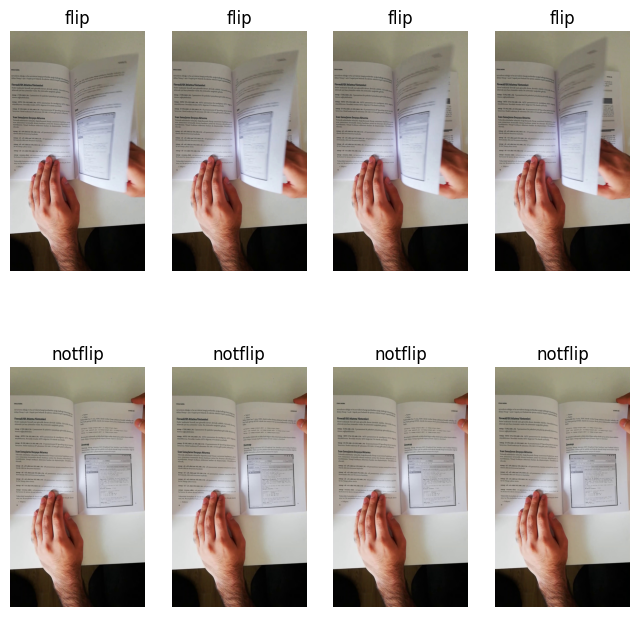

In [6]:
%matplotlib inline

import matplotlib.image as mpimg
from pathlib import Path

# Data path to classes
flip_dir = os.path.join(train_dir ,"flip")
notflip_dir = os.path.join(train_dir, "notflip")

# Parameters for our graph; we'll output images in a 2x4 configuration
nrows = 2
ncols = 4

pic_index = 0 # Index for iterating over images
# Set up matplotlib fig, and size it to fit 2x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols*2, nrows*4)

pic_index+=8

flip_pix = [os.path.join(flip_dir, fname)
                for fname in os.listdir(flip_dir)[ pic_index-4:pic_index]
               ]

not_flip_pix = [os.path.join(notflip_dir, fname)
                for fname in os.listdir(notflip_dir)[ pic_index-4:pic_index]
               ]

for i, img_path in enumerate(flip_pix + not_flip_pix ):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.title.set_text(os.path.basename(os.path.dirname(img_path)))
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

### 5.1 Create IbrahimNet Model

In [7]:
class IbrahimNet(nn.Module):
    def __init__(self, num_classes=2):
        super(IbrahimNet, self).__init__()
       # Define Convolutional layers
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),  # Adjust based on pooling
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.model(x)

In [8]:
# create an instance of the model and move it to the device
model = IbrahimNet(num_classes=len(class_names)).to(device)

# view the model architecture
print(model)

IbrahimNet(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=100352, out_features=256, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [9]:
output = model(torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device))
print(f"Output shape: {output.shape}")  # Should be [1, num_classes

Output shape: torch.Size([1, 2])


### create optimizer 

In [10]:
# pass our network parameters to the optimizer  and define the loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

### Define the training process

In [11]:
# This function will train the model for one epoch and return the average loss and accuracy
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

       # running_loss += loss.item() * inputs.size(0)  # Accumulate loss
        #_, preds = torch.max(outputs, 1)  # Get predictions
        #correct_predictions += torch.sum(preds == labels.data)  # Count correct predictions
        #total_predictions += labels.size(0)  # Count total predictions

    #epoch_loss = running_loss / total_predictions  # Average loss for the epoch
    #epoch_acc = correct_predictions.double() / total_predictions  # Accuracy for the epoch

    return model, optimizer, criterion
#epoch_loss, epoch_acc.item()

print("✓ Model, optimizer, and loss function defined successfully")
print("✓ Training function defined successfully")
print("✓ All components are ready for training")
  #     This will print the loss and accuracy for the last epoch

✓ Model, optimizer, and loss function defined successfully
✓ Training function defined successfully
✓ All components are ready for training


### Define the Testing process

In [12]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    # set network to evaluation mode
    # layer like dropout will be disabled during evaluation
    with torch.no_grad():  # Disable gradient computation for evaluation
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss

            running_loss += loss.item() * inputs.size(0)  # Accumulate loss
            _, preds = torch.max(outputs, 1)  # Get predictions
            correct_predictions += torch.sum(preds == labels.data)  # Count correct predictions
            total_predictions += labels.size(0)  # Count total predictions

    epoch_loss = running_loss / total_predictions  # Average loss for the epoch
    epoch_acc = correct_predictions.double() / total_predictions  # Accuracy for the epoch

    return epoch_loss, epoch_acc.item()
print("✓ Evaluation function defined successfully")

✓ Evaluation function defined successfully


### The training process

In [13]:
training_losses = []
validation_losses = []
training_accuracies = []
validation_accuracies = []


In [14]:
# Set the number of epochs to train
num_epochs = 5

for epoch in tqdm(range(num_epochs), desc="Epochs", leave=False):
    # Train the model for one epoch
    model, optimizer, criterion = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on training data
    train_loss, train_acc = evaluate_model(model, train_loader, criterion, device)
    training_losses.append(train_loss)
    training_accuracies.append(train_acc)

    # Evaluate on validation data
    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
    validation_losses.append(val_loss)
    

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epochs:  20%|██        | 1/5 [08:53<35:33, 533.37s/it]

Epoch 1/5
Training Loss: 0.5610, Training Accuracy: 0.7089
Validation Loss: 0.5194, Validation Accuracy: 0.7374


Epochs:  40%|████      | 2/5 [17:40<26:28, 529.43s/it]

Epoch 2/5
Training Loss: 0.3577, Training Accuracy: 0.8333
Validation Loss: 0.3571, Validation Accuracy: 0.8408


Epochs:  60%|██████    | 3/5 [26:21<17:31, 525.60s/it]

Epoch 3/5
Training Loss: 0.2863, Training Accuracy: 0.8864
Validation Loss: 0.2834, Validation Accuracy: 0.8799


Epochs:  80%|████████  | 4/5 [34:35<08:33, 513.45s/it]

Epoch 4/5
Training Loss: 0.2186, Training Accuracy: 0.9204
Validation Loss: 0.2154, Validation Accuracy: 0.9218


Epoch 5/5
Training Loss: 0.1840, Training Accuracy: 0.9336
Validation Loss: 0.1567, Validation Accuracy: 0.9302


### plot the figuer 

Text(0.5, 1.0, 'IbrahimNet Loss over Epochs')

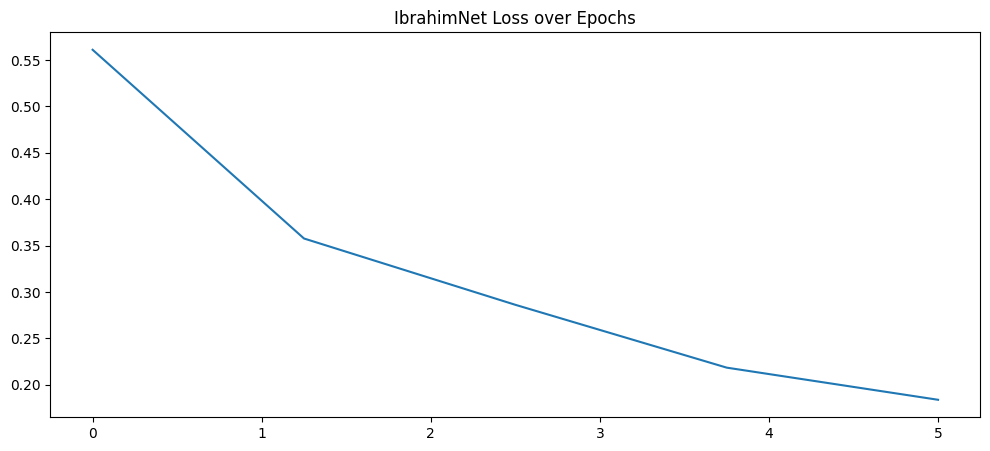

In [15]:
plt.figure(figsize=(12, 5))
train_x=np.linspace(0, num_epochs, len(training_losses))
plt.plot(train_x, training_losses)
plt.title('IbrahimNet Loss over Epochs')

Text(0.5, 1.0, 'IbrahimNet Accuracy over Epochs')

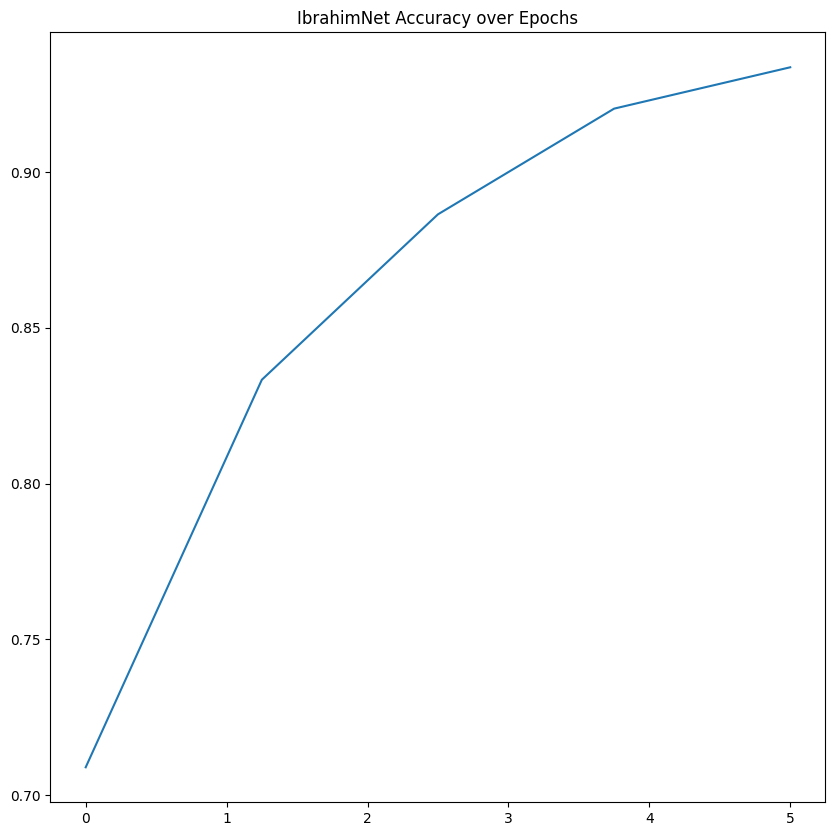

In [16]:
plt.figure(figsize=(10, 10))
train_x=np.linspace(0, num_epochs, len(training_accuracies))
plt.plot(train_x, training_accuracies, label='Training Accuracy')


val_x=np.linspace(0, num_epochs, len(validation_accuracies))
plt.plot(val_x, validation_accuracies, label='Validation Accuracy')
plt.title('IbrahimNet Accuracy over Epochs')

## Evaluate

In [19]:
# call the evaluate_model function to get the final test loss and accuracy
test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_accuracy:.4f},  Test Loss : {test_loss:.4f}")


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Test Accuracy: 0.9464,  Test Loss : 0.1417


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


<Figure size 800x600 with 0 Axes>

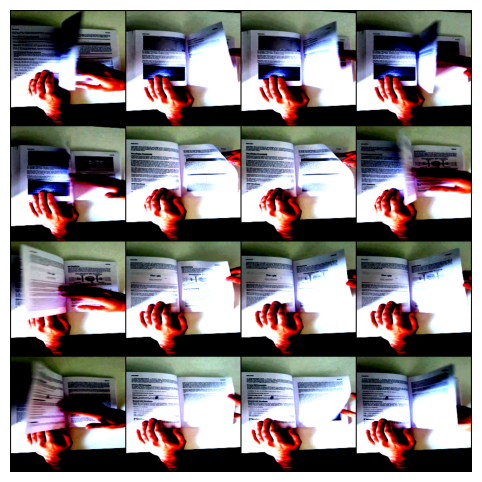

In [18]:
# Evaluate the model on the test set
with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(test_loader, desc="Testing", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

plt.figure(figsize=(8, 6))
plt.figure(figsize=(8, 6))
images = torch.stack([test_dataset[i][0] for i in range(16)])
out = torchvision.utils.make_grid(images, nrow=4)
plt.imshow(out.permute(1, 2, 0))
plt.axis('off')
plt.imshow(out.permute(1, 2, 0))